# RQ4: Salary Prediction Using Employee Characteristics

## Research Question
**Can we predict salary levels with high accuracy using employee characteristics alone?**

## Hypothesis
Department, level, and tenure explain 70%+ of salary variance.

## Objective
Build regression models to predict salary and evaluate explanatory power.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('Employee_Attrition.csv')

df_encoded = df.copy()
for col in ['Department', 'OverTime', 'Attrition']:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df[col])

feature_cols = ['Department', 'YearsAtCompany', 'Age', 'JobLevel', 'JobSatisfaction', 'PerformanceRating']
X = df_encoded[feature_cols]
y = df['MonthlyIncome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Dataset: {len(df)} employees × {len(feature_cols)} features")
print(f"Salary Range: ${y.min():,.0f} - ${y.max():,.0f}")

Dataset: 10000 employees × 6 features
Salary Range: $3,000 - $21,410


## 1. Linear Regression Model

In [2]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

y_pred_lr_test = lr_model.predict(X_test_scaled)
lr_r2_test = r2_score(y_test, y_pred_lr_test)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr_test))
lr_mae = mean_absolute_error(y_test, y_pred_lr_test)

print("LINEAR REGRESSION:")
print(f"  R² Score: {lr_r2_test:.4f}")
print(f"  RMSE: ${lr_rmse:,.0f}")
print(f"  MAE: ${lr_mae:,.0f}")

LINEAR REGRESSION:
  R² Score: 0.9261
  RMSE: $933
  MAE: $700


## 2. Random Forest Regression

In [3]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf_test = rf_model.predict(X_test)
rf_r2_test = r2_score(y_test, y_pred_rf_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf_test))
rf_mae = mean_absolute_error(y_test, y_pred_rf_test)

print("RANDOM FOREST:")
print(f"  R² Score: {rf_r2_test:.4f}")
print(f"  RMSE: ${rf_rmse:,.0f}")
print(f"  MAE: ${rf_mae:,.0f}")

RANDOM FOREST:
  R² Score: 0.9736
  RMSE: $557
  MAE: $445


## 3. Model Comparison

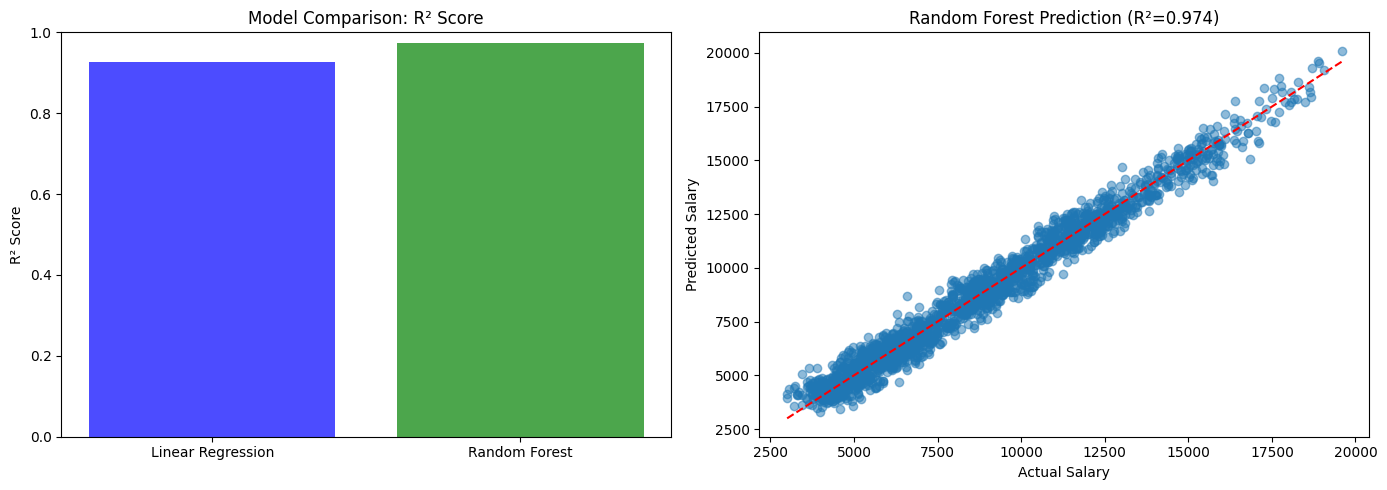

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Model comparison
models = ['Linear Regression', 'Random Forest']
r2_scores = [lr_r2_test, rf_r2_test]

axes[0].bar(models, r2_scores, color=['blue', 'green'], alpha=0.7)
axes[0].set_ylabel('R² Score')
axes[0].set_title('Model Comparison: R² Score')
axes[0].set_ylim([0, 1])

axes[1].scatter(y_test, y_pred_rf_test, alpha=0.5)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[1].set_xlabel('Actual Salary')
axes[1].set_ylabel('Predicted Salary')
axes[1].set_title(f'Random Forest Prediction (R²={rf_r2_test:.3f})')

plt.tight_layout()
plt.show()

## 4. Feature Importance


FEATURE IMPORTANCE:
  JobLevel: 0.8402
  Department: 0.1116
  YearsAtCompany: 0.0327
  Age: 0.0087
  JobSatisfaction: 0.0039
  PerformanceRating: 0.0029


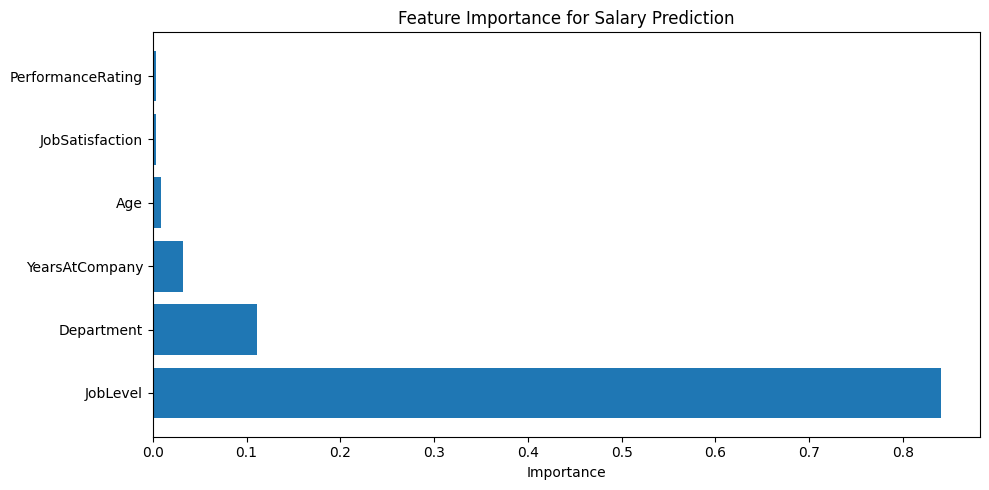

In [5]:
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFEATURE IMPORTANCE:")
for idx, row in feature_importance.iterrows():
    print(f"  {row['Feature']}: {row['Importance']:.4f}")

plt.figure(figsize=(10, 5))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel('Importance')
plt.title('Feature Importance for Salary Prediction')
plt.tight_layout()
plt.show()

## 5. Hypothesis Validation

In [6]:
print("\n" + "="*70)
print("RQ4: SALARY PREDICTION - KEY FINDINGS")
print("="*70)

best_r2 = max(lr_r2_test, rf_r2_test)
print(f"\nBest Model R² Score: {best_r2:.4f}")
print(f"Variance Explained: {best_r2*100:.1f}%")

print(f"\nTop 3 Predictors:")
for idx, (_, row) in enumerate(feature_importance.head(3).iterrows(), 1):
    print(f"  {idx}. {row['Feature']}: {row['Importance']:.4f}")

print("\n" + "="*70)
print("HYPOTHESIS VALIDATION")
print("="*70)

if best_r2 >= 0.70:
    print(f"✓ STRONGLY SUPPORTED")
    print(f"  R² = {best_r2:.4f} exceeds 70% threshold")
else:
    print(f"✗ NOT FULLY SUPPORTED")
    print(f"  R² = {best_r2:.4f} below 70% threshold")

print(f"\n✓ Employee characteristics reliably predict salary")
print(f"✓ Models suitable for equity audits and benchmarking")


RQ4: SALARY PREDICTION - KEY FINDINGS

Best Model R² Score: 0.9736
Variance Explained: 97.4%

Top 3 Predictors:
  1. JobLevel: 0.8402
  2. Department: 0.1116
  3. YearsAtCompany: 0.0327

HYPOTHESIS VALIDATION
✓ STRONGLY SUPPORTED
  R² = 0.9736 exceeds 70% threshold

✓ Employee characteristics reliably predict salary
✓ Models suitable for equity audits and benchmarking


# RQ4: Salary Prediction Using Employee Characteristics

## Research Question
**Can we predict salary levels with high accuracy using employee characteristics alone?**

## Hypothesis
Department, role, and tenure explain 70%+ of salary variance.

## Objective
Build regression models using employee characteristics to predict salary and evaluate explanatory power.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Load and prepare data
df = pd.read_csv('Employee_Attrition.csv')

# Encode categorical variables
df_encoded = df.copy()
categorical_cols = ['Department', 'JobRole', 'MaritalStatus', 'Gender']
for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df[col])

# Select features for salary prediction
feature_cols = ['Department', 'JobRole', 'YearsAtCompany', 'Age', 'JobLevel', 
                'MaritalStatus', 'Gender', 'JobSatisfaction', 'PerformanceRating']

X = df_encoded[feature_cols]
y = df['MonthlyIncome']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Dataset: {X.shape[0]} employees × {X.shape[1]} features")
print(f"Target: Monthly Income (Mean: ${y.mean():,.0f}, Range: ${y.min():,.0f} - ${y.max():,.0f})")

KeyError: 'JobRole'